# PyTorch workflow

Let's explore end to end workflow

In [2]:
what_were_convering = {1: "data (prepare and load)",
                       2: "build model",
                       3: "fitting the model to data (training)",
                       4: "making prediction",
                       5: "saving and loading a model"}
what_were_convering

{1: 'data (prepare and load)',
 2: 'build model',
 3: 'fitting the model to data (training)',
 4: 'making prediction',
 5: 'saving and loading a model'}

In [4]:
import torch
from torch import nn
import matplotlib.pyplot as plt

torch.__version__

'2.8.0+cu126'

## 1. Data preparing and loading
* Data can be anything (sheet, sql, nosql, images, vids, audio, dna)
* Machine learning is a game of two parts. get numerical representation -> learn paterns

Use linear ligression formula

In [32]:
# Create known params
w = 0.7
b = 0.3

start = 0
end = 1
step = 0.02
X= torch.arange(start,end,step)
# torch.manual_seed(0)
# noise = torch.randn(len(X))
y = w * X ** b

X[40:], y[40:], len(X), len(y)

(tensor([0.8000, 0.8200, 0.8400, 0.8600, 0.8800, 0.9000, 0.9200, 0.9400, 0.9600,
         0.9800]),
 tensor([0.6547, 0.6595, 0.6643, 0.6690, 0.6737, 0.6782, 0.6827, 0.6871, 0.6915,
         0.6958]),
 50,
 50)

### Splitting data into training validation and test sets

In [33]:
train_split = int(0.85 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]
len(X_train), len(y_train), len(X_test), len(y_test)

(42, 42, 8, 8)

In [34]:
# Visualization

def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):
  """
  Plots training data, test data and compares prediction
  """
  plt.figure(figsize=(10,7))
  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training Data")
  plt.scatter(test_data, test_labels, c="r", s=4, label="Testing Data")
  if predictions is not None:
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # show legend
  plt.legend(prop={"size":14})


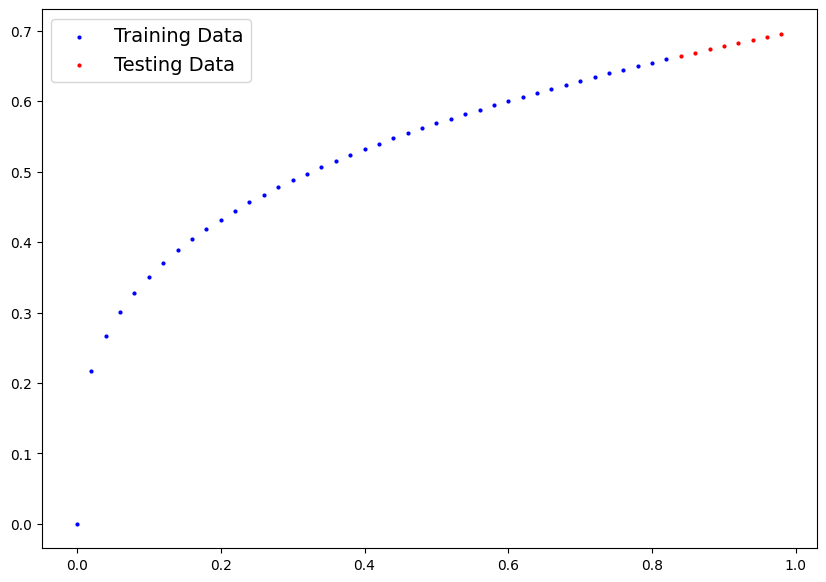

In [35]:
plot_predictions()

## Build model
Pytorch model

In [36]:
# Create a linear regression model class
class LinearRegressionModel(nn.Module): # everythin in pytorch inherits from nn.Module
  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter(torch.randn(1,
                                            requires_grad=True,
                                            dtype=torch.float))
    self.bias = nn.Parameter(torch.randn(1,requires_grad=True, dtype=torch.float))

  # forward propogation
  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.weights * x ** self.bias # my own formula it should be linear regression


### PyTorch model building essentiaals

* torch.nn - all the buildings for computation graphs (a neural netwoork can be computational graph)
* torch.nn.Parameter - what param should out model try and learn to tweak it exactly like out data output, torch.nn will set these for us in future
* torch.nn.Module - the base class for all nn module, if subclass, should create your own forward method
* torch.optim - model optimization


In [37]:
x = LinearRegressionModel()
x.forward(X_train)

tensor([0.0000, 0.0167, 0.0321, 0.0469, 0.0614, 0.0757, 0.0899, 0.1039, 0.1178,
        0.1315, 0.1452, 0.1588, 0.1723, 0.1857, 0.1991, 0.2124, 0.2257, 0.2389,
        0.2521, 0.2652, 0.2783, 0.2913, 0.3043, 0.3173, 0.3302, 0.3431, 0.3560,
        0.3688, 0.3817, 0.3944, 0.4072, 0.4199, 0.4326, 0.4453, 0.4579, 0.4706,
        0.4832, 0.4958, 0.5083, 0.5209, 0.5334, 0.5459],
       grad_fn=<MulBackward0>)